In [212]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import arch
import scipy.stats as stats

In [213]:
data = pd.read_csv("GDAXI.csv").iloc[::-1].reset_index(drop=True)
data.head()

,Date,Open,High,Low,Close
0,01/03/00,6961.72,6750.76,6750.76,6750.76
1,01/04/00,6747.24,6586.95,6586.95,6586.95
2,01/05/00,6585.85,6502.07,6502.07,6502.07
3,01/06/00,6501.45,6474.92,6474.92,6474.92
4,01/07/00,6489.94,6780.96,6780.96,6780.96


In [214]:
X = np.log(data[" Close"]).diff().dropna()
L_train,L_test = -100*X[:1270],-100*X[1270:]

In [215]:
mu_train,mu_test = np.mean(L_train),np.mean(L_test)
sigma_train,sigma_test = np.std(L_train,ddof=1),np.std(L_test,ddof=1)


var975_cv = mu_train+sigma_train*stats.norm.ppf(0.975)
ES975_cv = mu_train+sigma_train*stats.norm.pdf(stats.norm.ppf(0.975))/(1-0.975)
print(mu_train,mu_test)
print(sigma_train,sigma_test)

0.035670218773583943 -0.028630755958284414
1.835790834840644 1.3650107932975217


In [216]:
var975_h = np.quantile(L_train,0.975)
ES975_h = np.mean(L_train[L_train>var975_h])

In [217]:
print(var975_cv,ES975_cv)
print(var975_h,ES975_h)

3.6337541382099645 4.327387158361804
3.9407909472677716 5.04990452152505


In [218]:
n_train,n_test = len(L_train),len(L_test)
c_cv_test,c_cv_train = len(L_test[L_test>var975_cv])/n_test, len(L_train[L_train>var975_cv])/n_train
c_h_test,c_h_train = len(L_test[L_test>var975_h])/n_test, len(L_train[L_train>var975_h])/n_train


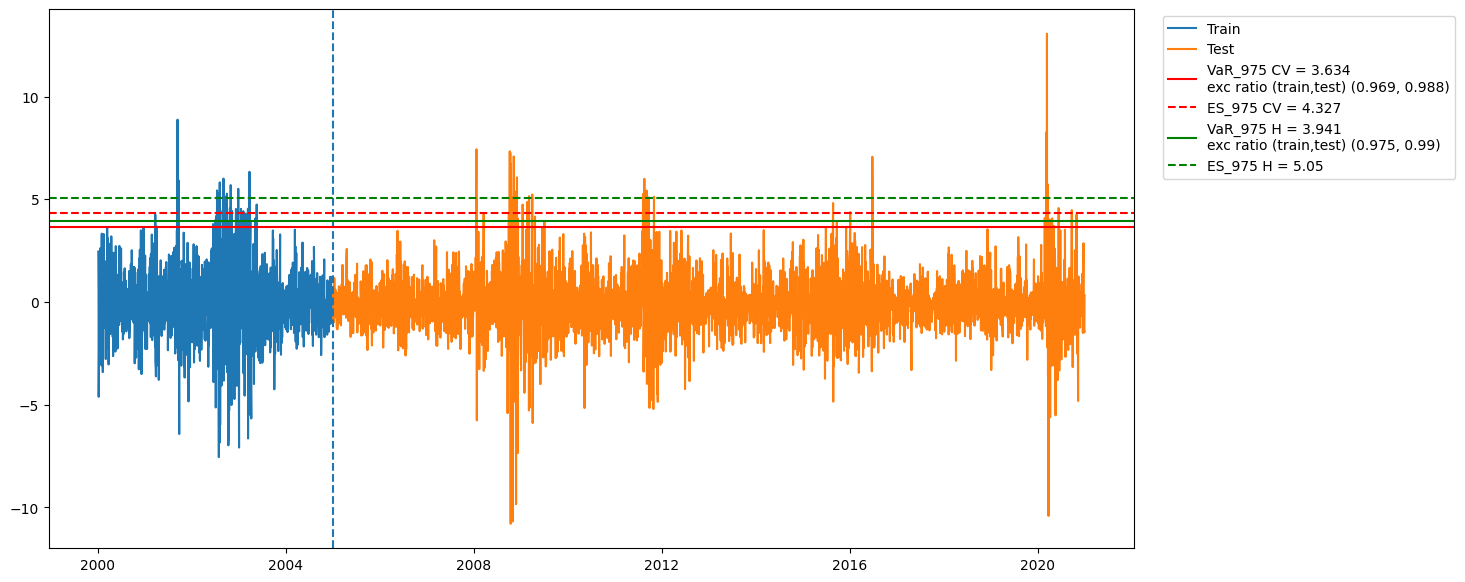

In [219]:
dates = pd.to_datetime(data["Date"], format="%m/%d/%y")
plt.figure(figsize=(14,7))
plt.plot(dates[1:1271],L_train,label="Train")
plt.plot(dates[1271:],L_test,label="Test")
plt.axvline(dates[1271],linestyle="--")
plt.axhline(var975_cv,color="red",label=f"VaR_975 CV = {round(var975_cv,3)} \nexc ratio (train,test) {round(1-c_cv_train,3),round(1-c_cv_test,3)}")
plt.axhline(ES975_cv,color="red",linestyle="--",label=f"ES_975 CV = {round(ES975_cv,3)}")
plt.axhline(var975_h,color="green",label=f"VaR_975 H = {round(var975_h,3)} \nexc ratio (train,test) {round(1-c_h_train,3),round(1-c_h_test,3)}")
plt.axhline(ES975_h,color="green",linestyle="--",label=f"ES_975 H = {round(ES975_h,3)}")

plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.show()

In [220]:
model = arch.arch_model(L_train,vol="GARCH",p=1,q=1)
res = model.fit(disp="off")

print(f"alpha0 = {round(res.params['omega'],3)}")
print(f"alpha1 = {round(res.params['alpha[1]'],3)}")
print(f"beta1 = {round(res.params['beta[1]'],3)}")
alpha0=res.params['omega'];alpha1 = res.params['alpha[1]']; beta1=res.params['beta[1]']


alpha0 = 0.023
alpha1 = 0.092
beta1 = 0.902


In [221]:
np.random.seed(6)
N = len(L_train)+len(L_test)
Ld =np.concatenate((L_train,L_test))
V = np.zeros(shape=(N))
V[0] = alpha0/(1-(alpha1+beta1))
for t in range(0,N-1):
    V[t+1] = alpha0+alpha1*Ld[t]**2+beta1*V[t]

0.030061007365902052 1.0014844766370437


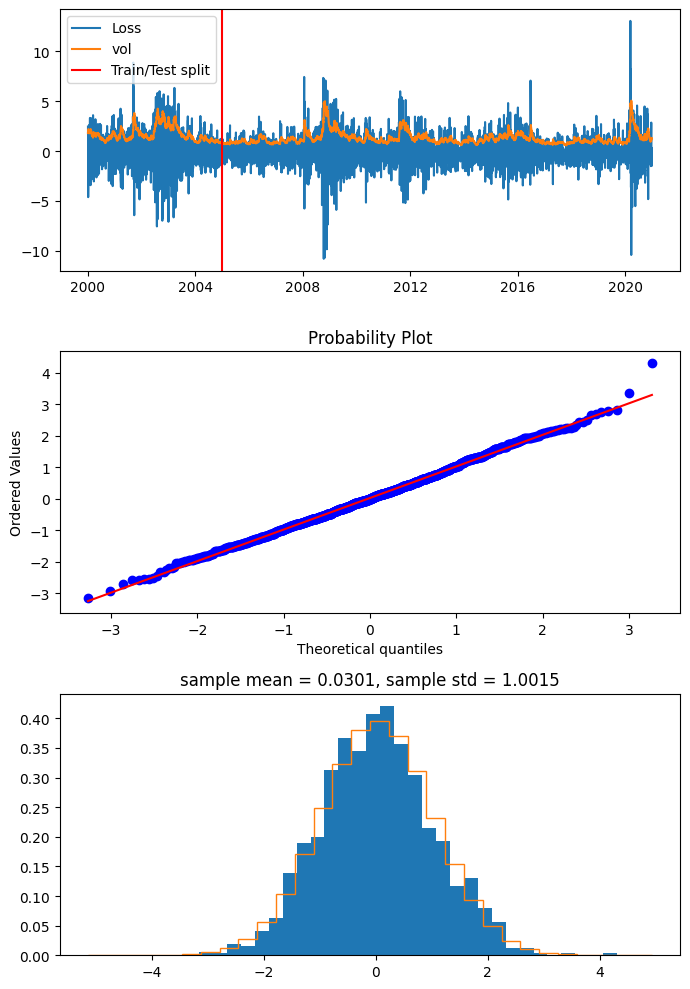

In [222]:

Z = (Ld/np.sqrt(V))[:1270]
mu_Z = np.mean(Z)
sigma_Z = np.std(Z,ddof=1)
print(mu_Z,sigma_Z)

plt.figure(figsize=(7,10))
plt.subplot(3,1,1)
plt.plot(dates[1:],Ld,label="Loss")
plt.plot(dates[1:],np.sqrt(V),label="vol")
plt.axvline(dates[1271],color="red",label="Train/Test split")
plt.legend()

plt.subplot(3,1,2)
stats.probplot(Z,plot=plt)
plt.subplot(3,1,3)
plt.hist(Z,bins=30,density=True)
plt.hist(np.random.normal(mu_Z,sigma_Z,1000*n_train),bins=30,density=True,histtype="step")
plt.title(f"sample mean = {round(mu_Z,4)}, sample std = {round(sigma_Z,4)}")
plt.tight_layout()
plt.show()

In [226]:
# # n_train,n_test = len(L_train),len(L_test)
# c_cv_test,c_cv_train = len(L_test[L_test>var975_cv])/n_test, len(L_train[L_train>var975_cv])/n_train
# c_h_test,c_h_train = len(L_test[L_test>var975_h])/n_test, len(L_train[L_train>var975_h])/n_train

# 
# dates = pd.to_datetime(data["Date"], format="%m/%d/%y")
# plt.figure(figsize=(14,7))
# plt.plot(dates[1:1271],L_train,label="Train")
# plt.plot(dates[1271:],L_test,label="Test")
# plt.axvline(dates[1271],linestyle="--")
# plt.axhline(var975_cv,color="red",label=f"VaR_975 CV = {round(var975_cv,3)} \nexc ratio (train,test) {round(1-c_cv_train,3),round(1-c_cv_test,3)}")
# plt.axhline(ES975_cv,color="red",linestyle="--",label=f"ES_975 CV = {round(ES975_cv,3)}")
# plt.axhline(var975_h,color="green",label=f"VaR_975 H = {round(var975_h,3)} \nexc ratio (train,test) {round(1-c_h_train,3),round(1-c_h_test,3)}")
# plt.axhline(ES975_h,color="green",linestyle="--",label=f"ES_975 H = {round(ES975_h,3)}")

# plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
# plt.show()

### use the format of above to plot the results nicely, it suffices to consider the historical part i.e. _h


Z_var975_cv = mu_Z+sigma_Z*stats.norm.ppf(0.975)
Z_ES975_cv = mu_Z+sigma_Z*stats.norm.pdf(stats.norm.ppf(0.975))/(1-0.975)

Z_var975_h = np.quantile(Z,0.975)
Z_ES975_h = np.mean(Z[Z>Z_var975_h])

print(Z_var975_cv,Z_var975_h)
print(Z_ES975_cv,Z_ES975_h)

Lt_var975_cv = np.sqrt(V)*Z_var975_cv
Lt_var975_h = np.sqrt(V)*Z_var975_h
Lt_ES975_cv = np.sqrt(V)*Z_ES975_cv
Lt_ES975_h = np.sqrt(V)*Z_ES975_h
# plt.figure(figsize=(16,8))
# plt.plot(Ld,lw=0.3)
# # plt.plot(Lt_var975_cv,linewidth=0.3)
# plt.plot(Lt_var975_h,linewidth=0.3)
# # plt.plot(Lt_ES975_cv,linewidth=0.3)
# plt.plot(Lt_ES975_h,linewidth=0.3)
# plt.plot(np.sqrt(V),lw=0.3)
# plt.show()


1.9929345126504527 2.0064623700137365
2.3713342131943533 2.3888607828984325


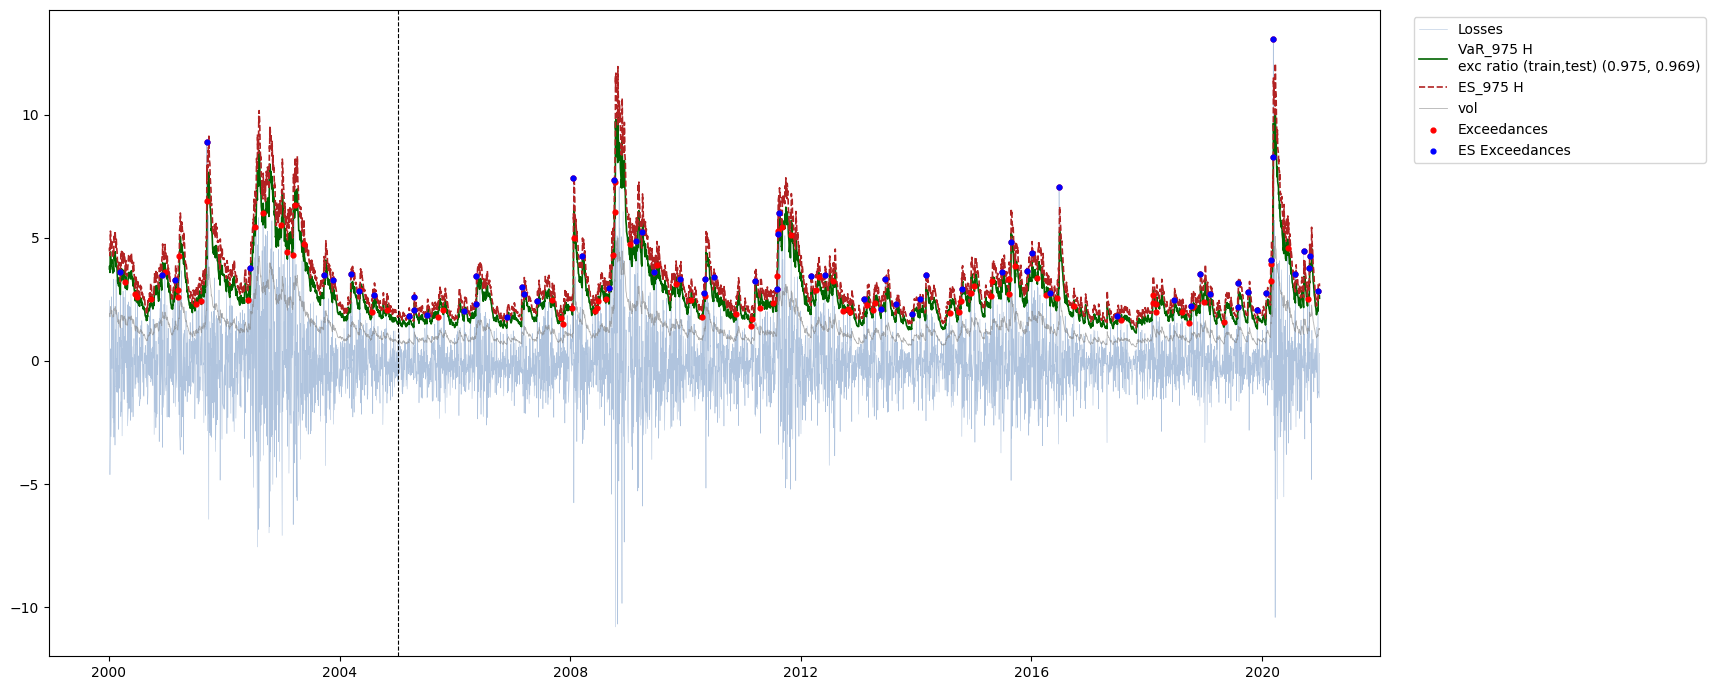

In [237]:
n = len(Ld)
d = dates[-n:]
exc = Ld > Lt_var975_h
c_tr, c_te = np.mean(exc[:1270]), np.mean(exc[1270:])

plt.figure(figsize=(14,7))
plt.plot(d, Ld, lw=0.4, color="lightsteelblue", label="Losses")
plt.plot(d, Lt_var975_h, color="darkgreen", lw=1.2,
         label=f"VaR_975 H\nexc ratio (train,test) {round(1-c_tr,3), round(1-c_te,3)}")
plt.plot(d, Lt_ES975_h, color="firebrick", ls="--", lw=1.2, label="ES_975 H")
plt.plot(d, np.sqrt(V), color="gray", lw=0.6, alpha=0.6, label="vol")
plt.scatter(d[exc], Ld[exc], color="red", s=12, zorder=5, label="Exceedances")
plt.axvline(d.iloc[1270], color="black", ls="--", lw=0.8)
exc_es = Ld > Lt_ES975_h
plt.scatter(d[exc_es], Ld[exc_es], color="blue", s=12, zorder=6, label="ES Exceedances")
plt.tight_layout()
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

plt.show()